In [1]:
#Nike Sales Analysis

##Objective

#This project analyzes Nike retail sales data using Python to identify trends in revenue, 
#profitability, product performance, regional sales, and sales channels. The analysis
#includes data cleaning, exploratory data analysis (EDA), and business recommendations 
#based on the findings.

In [4]:
import pandas as pd

df = pd.read_csv("Nike_Sales_Uncleaned.csv")

df.info() #gives a quick summary of loaded data
df.isnull().sum() #missing values in size, units_sold, MRP, discount_applied, and order date

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              1990 non-null   object 
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null   object 
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 254.0+ KB


Order_ID               0
Gender_Category        0
Product_Line           0
Product_Name           0
Size                 510
Units_Sold          1235
MRP                 1254
Discount_Applied    1668
Revenue                0
Order_Date           616
Sales_Channel          0
Region                 0
Profit                 0
dtype: int64

In [5]:
##Initial inspection revealed missing values, inconsistent date formats, and mixed data types
#that required cleaning before analysis.

In [6]:
df.isnull().mean() * 100       #gives percentage of missing values

Order_ID             0.00
Gender_Category      0.00
Product_Line         0.00
Product_Name         0.00
Size                20.40
Units_Sold          49.40
MRP                 50.16
Discount_Applied    66.72
Revenue              0.00
Order_Date          24.64
Sales_Channel        0.00
Region               0.00
Profit               0.00
dtype: float64

In [7]:
df.describe()

,Order_ID,Units_Sold,MRP,Discount_Applied,Revenue,Profit
count,2500.000000,1265.000000,1246.000000,832.000000,2500.000000,2500.000000
mean,3194.352400,1.482213,6039.863395,0.631022,274.873716,1376.012848
std,749.972638,1.696947,2315.746826,0.365500,2023.773550,1478.671013
min,2000.000000,-1.000000,2006.630000,0.000000,-7561.590000,-1199.450000
25%,2534.750000,0.000000,4038.902500,0.320000,0.000000,93.532500
50%,3192.500000,2.000000,6110.030000,0.615000,0.000000,1371.385000
75%,3841.250000,3.000000,8022.187500,0.962500,0.000000,2660.645000
max,4499.000000,4.000000,9996.220000,1.250000,37169.350000,3999.210000


In [8]:
df = df.drop(columns=["Discount_Applied"])   #discount applied not important

In [9]:
df.columns

Index(['Order_ID', 'Gender_Category', 'Product_Line', 'Product_Name', 'Size',
       'Units_Sold', 'MRP', 'Revenue', 'Order_Date', 'Sales_Channel', 'Region',
       'Profit'],
      dtype='object')

In [10]:
df[["Size", "Units_Sold", "MRP", "Order_Date"]].head()

,Size,Units_Sold,MRP,Order_Date
0,M,NaN,NaN,2024-03-09
1,M,3.0,4957.93,2024-07-09
2,M,4.0,NaN,NaN
3,L,NaN,9673.57,04-10-2024
4,XL,NaN,NaN,2024/09/12


In [11]:
#CLEANING MISSING ROWS NOW
df["Size"] = df["Size"].fillna("Unknown")

In [ ]:
#dropna = removes any row containing missing value/data
#fillna(#) = fills any column with whatever # I put

In [12]:
df["Units_Sold"] = df["Units_Sold"].fillna(df["Units_Sold"].median())
#use median since mean might give a higher retail price

In [13]:
df["Units_Sold"].describe()

count    2500.000000
mean        1.738000
std         1.234328
min        -1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         4.000000
Name: Units_Sold, dtype: float64

In [14]:
df = df.dropna(subset=["Units_Sold", "MRP"])

In [15]:
df = df.dropna(subset=["Order_Date"])

In [16]:
df["Size"] = df["Size"].fillna("Unknown")

In [17]:
df.isnull().sum()

Order_ID           0
Gender_Category    0
Product_Line       0
Product_Name       0
Size               0
Units_Sold         0
MRP                0
Revenue            0
Order_Date         0
Sales_Channel      0
Region             0
Profit             0
dtype: int64

In [18]:
df.info()
#float64 --> numbers with decimals

<class 'pandas.core.frame.DataFrame'>
Index: 939 entries, 1 to 2499
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         939 non-null    int64  
 1   Gender_Category  939 non-null    object 
 2   Product_Line     939 non-null    object 
 3   Product_Name     939 non-null    object 
 4   Size             939 non-null    object 
 5   Units_Sold       939 non-null    float64
 6   MRP              939 non-null    float64
 7   Revenue          939 non-null    float64
 8   Order_Date       939 non-null    object 
 9   Sales_Channel    939 non-null    object 
 10  Region           939 non-null    object 
 11  Profit           939 non-null    float64
dtypes: float64(4), int64(1), object(7)
memory usage: 95.4+ KB


In [19]:
#are there duplicates
df.duplicated().sum()

np.int64(0)

In [20]:
#are there a lot of negatives
df[df["Revenue"] < 0]
df[df["Units_Sold"] <= 0]

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Revenue,Order_Date,Sales_Channel,Region,Profit
19,2019,Kids,Running,Air Zoom,6,0.0,3424.06,0.00,2025/01/17,Online,Hyderabad,1915.24
21,2021,Men,Running,Free RN,L,-1.0,7086.70,-2409.48,2024/11/19,Retail,Hyd,-1120.49
59,2059,Kids,Soccer,Phantom GT,Unknown,-1.0,9507.54,0.00,2023-12-27,Retail,Delhi,291.28
66,2066,Men,Soccer,Phantom GT,XL,-1.0,5259.05,0.00,2024-12-10,Online,Mumbai,1022.82
79,2079,Men,Running,Pegasus Turbo,XL,-1.0,4322.06,0.00,2025/01/19,Online,bengaluru,279.78
...,...,...,...,...,...,...,...,...,...,...,...,...
2410,4410,Men,Basketball,Kyrie Flytrap,XL,-1.0,5967.57,596.76,2024-01-26,Retail,Mumbai,-1011.68
2425,4425,Women,Running,Air Zoom,L,0.0,4034.25,0.00,2023-09-04,Retail,Delhi,363.80
2449,4449,Men,Lifestyle,Air Force 1,9,0.0,5053.29,0.00,2025/02/24,Retail,Kolkata,3206.34
2451,4451,Women,Lifestyle,Dunk Low,Unknown,0.0,2049.73,0.00,08-11-2024,Online,Pune,2543.16


In [21]:
#error because order date should be seen as a datetime not object
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

ValueError: time data "04-10-2024" doesn't match format "%Y-%m-%d", at position 1. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [23]:
# Fixed the missing opening quotation mark before 'Order_Date'
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

In [24]:
#since there's multiple date formats like 2024-07-09 or 
#04-10-2024, having mixed tells Pandas
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    format="mixed",
    dayfirst=True
)

In [25]:
print(df["Order_Date"].dtype)

datetime64[ns]


In [ ]:
#DONE:
#loaded data
#inspected it
#cleaned missing values/na's
#fixed data types

In [ ]:
#NEXT STEP: Exploratory Analysis

In [26]:
df.groupby("Product_Line")["Revenue"].sum().sort_values(ascending=False).head(10)
#groupby --> group two columns together
#basketball, training, and soccer are the best sellers

Product_Line
Basketball    154210.82
Training      151860.79
Soccer        114928.05
Lifestyle      96174.12
Running        29612.38
Name: Revenue, dtype: float64

In [27]:
df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)
#regions with the most revenue

Region
Kolkata      140662.90
hyderbad      76277.12
Pune          75660.66
Mumbai        75434.85
Delhi         72002.62
Bangalore     42892.16
bengaluru     34895.37
Hyderabad     28313.58
Hyd             646.90
Name: Revenue, dtype: float64

In [ ]:
#Kolkata generated the highest revenue, indicating strong customer demand. Nike may benefit 
#from expanding promotional campaigns or inventory in this market. 

In [28]:
df.groupby("Sales_Channel")["Revenue"].sum()

Sales_Channel
Online    302639.18
Retail    244146.98
Name: Revenue, dtype: float64

In [29]:
df.groupby("Product_Line")["Profit"].sum().sort_values(ascending=False)

Product_Line
Lifestyle     269959.62
Soccer        255231.56
Basketball    251173.09
Running       251026.26
Training      211221.97
Name: Profit, dtype: float64

In [30]:
#trends over time
df["Month"] = df["Order_Date"].dt.to_period("M")
#dt.to_period changes 'year-day-month' to 'year-month'

In [31]:
df.groupby("Month")["Revenue"].sum()

Month
2023-07        0.00
2023-08     8781.29
2023-09    21195.72
2023-10        0.00
2023-11     5667.01
2023-12    21586.98
2024-01    16262.45
2024-02     -112.18
2024-03    -2652.04
2024-04    -1799.14
2024-05    10468.87
2024-06      157.68
2024-07     4612.57
2024-08        0.00
2024-09        0.00
2024-10     4270.86
2024-11    11863.29
2024-12    10474.25
2025-01     6890.56
2025-02      482.47
2025-03     7695.58
2025-04     8687.88
2025-05        0.00
2025-06        0.00
2025-07        0.00
Freq: M, Name: Revenue, dtype: float64

In [ ]:
#since trends are hard to understand from looking at a table
#I'll create charts

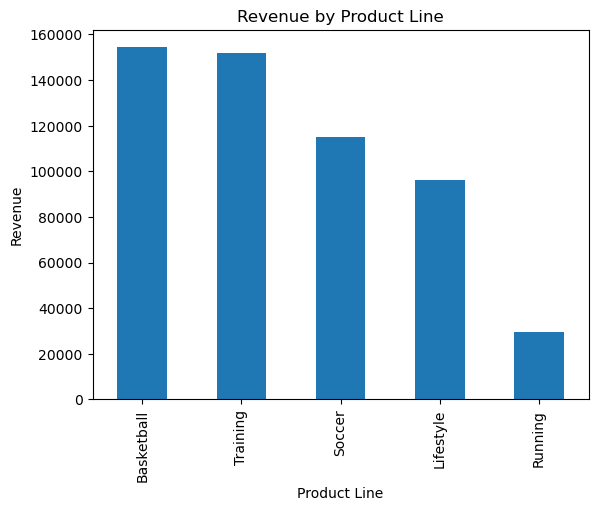

In [32]:
import matplotlib.pyplot as plt

df.groupby("Product_Line")["Revenue"].sum()\
    .sort_values(ascending=False)\
    .plot(kind="bar")

plt.title("Revenue by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Revenue")
plt.show()

In [ ]:
#Basketball products generated the highest total revenue, suggesting this category is one of 
#Nike's strongest-performing product line. Increasing inventory or marketing investment for
#this category could further improve sales performance.

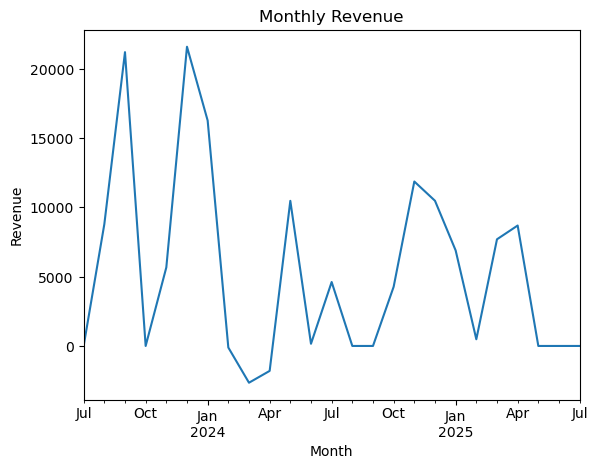

In [33]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue.plot(kind="line")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [ ]:
#Revenue peaked in late 2024 before declining sharply in the following months. This pattern
#may indicate seasonal demand, promotional events, or other business factors that influenced
#customer purchasing behavior.

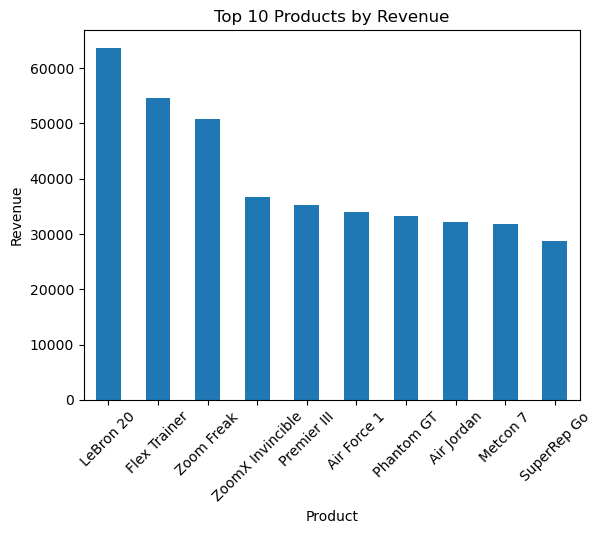

In [34]:
top_products = (
    df.groupby("Product_Name")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

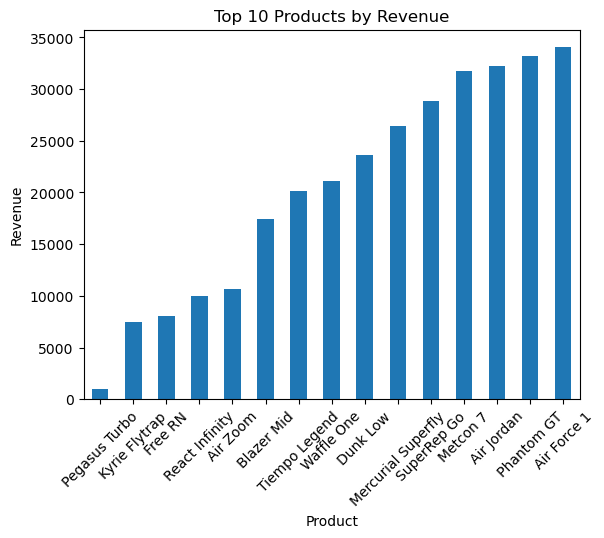

In [35]:
top_products = (
    df.groupby("Product_Name")["Revenue"]
      .sum()
      .sort_values(ascending=True)
      .head(15)
)

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [36]:
df["Product_Name"].value_counts()

Product_Name
Air Jordan            59
LeBron 20             57
Blazer Mid            54
Air Force 1           54
Phantom GT            52
SuperRep Go           50
Dunk Low              49
Flex Trainer          49
Zoom Freak            48
ZoomX Invincible      48
Free RN               46
React Infinity        46
Waffle One            45
Air Zoom              44
Mercurial Superfly    43
Premier III           43
Kyrie Flytrap         41
Pegasus Turbo         41
Tiempo Legend         36
Metcon 7              34
Name: count, dtype: int64

In [37]:
len(df)

939

In [ ]:
#Recommendations
#increase investment in top-performing product lines
#expand marketing in the highest revenue regions
#investigate why lower-performing product categories lag
#continue growing the strongest sales channel
#monitor monthly trends to anticipate seasonal demand

In [ ]:
#Conclusion
#This project demonstrates the complete analytics workflow:
#importing data
#cleaning data
#exploratory data analysis
#visualization
#business recommendations

#The analysis transformed raw sales data into actionable 
#that could support inventory, marketing, and strategic decision making.